In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn import metrics

### Read the csv

In [21]:
df = pd.read_csv('car_dataset.csv')

### Information about the dataset

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [23]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [24]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Check for missing data

In [25]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [26]:
df = df.dropna()

In [27]:
df.shape

(4340, 8)

# Analysis of categorical feature

In [28]:
df.fuel.value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [29]:
df.seller_type.value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

In [30]:
df.transmission.value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [31]:
df.owner.value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

### Encoding of categorical feature

In [32]:
categorical_columns = df.select_dtypes(include = ['str']).columns.tolist()

categorical_columns = categorical_columns[1:]

In [ ]:
encoder = OneHotEncoder(sparse_output = False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])

In [34]:
one_hot_df = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(categorical_columns))

In [35]:
df_encoded = pd.concat([df, one_hot_df], axis = 1)
df_encoded = df_encoded.drop(categorical_columns, axis = 1)

df_encoded.head()

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,2007,60000,70000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,Hyundai Verna 1.6 SX,2012,600000,100000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,Datsun RediGO T Option,2017,250000,46000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,Honda Amaze VX i-DTEC,2014,450000,141000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [39]:
df_encoded.corr(numeric_only= True)

,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
year,1.000000,0.413922,-0.419688,0.008792,0.121424,-0.025540,-0.051266,-0.114908,0.143464,-0.173703,0.100225,0.143800,-0.143800,0.438897,-0.186361,-0.292349,0.095795,-0.244308
selling_price,0.413922,1.000000,-0.192289,-0.037839,0.282947,-0.005095,-0.042434,-0.269453,0.205111,-0.236798,0.110176,0.530205,-0.530205,0.223889,-0.078725,-0.161986,0.048799,-0.111326
km_driven,-0.419688,-0.192289,1.000000,0.002107,0.285396,-0.001372,0.036652,-0.291139,-0.156465,0.182663,-0.089858,-0.120226,0.120226,-0.299731,0.097349,0.195203,-0.083445,0.194713
fuel_CNG,0.008792,-0.037839,0.002107,1.000000,-0.095696,-0.001464,-0.007040,-0.094382,-0.000926,0.006112,-0.014963,-0.032723,0.032723,-0.025832,0.040149,0.021062,-0.006048,-0.007575
fuel_Diesel,0.121424,0.282947,0.285396,-0.095696,1.000000,-0.015063,-0.072422,-0.970934,0.039364,-0.035314,-0.007911,0.048098,-0.048098,-0.000878,-0.021054,0.003524,-0.010575,0.009373
fuel_Electric,-0.025540,-0.005095,-0.001372,-0.001464,-0.015063,1.000000,-0.001108,-0.014856,0.027853,-0.026118,-0.002355,0.044746,-0.044746,-0.020804,-0.002094,0.025960,-0.000952,-0.004166
fuel_LPG,-0.051266,-0.042434,0.036652,-0.007040,-0.072422,-0.001108,1.000000,-0.071427,-0.032231,0.035122,-0.011324,-0.024764,0.024764,-0.033379,0.013384,0.030141,-0.004577,0.004836
fuel_Petrol,-0.114908,-0.269453,-0.291139,-0.094382,-0.970934,-0.014856,-0.071427,1.000000,-0.035360,0.029845,0.012489,-0.039614,0.039614,0.011296,0.011502,-0.012717,0.012427,-0.008502
seller_type_Dealer,0.143464,0.205111,-0.156465,-0.000926,0.039364,0.027853,-0.032231,-0.035360,1.000000,-0.937703,-0.084557,0.206163,-0.206163,0.224992,-0.067062,-0.165228,0.115054,-0.130250
seller_type_Individual,-0.173703,-0.236798,0.182663,0.006112,-0.035314,-0.026118,0.035122,0.029845,-0.937703,1.000000,-0.266904,-0.214163,0.214163,-0.252628,0.072322,0.186573,-0.107886,0.140823


In [41]:
x = df_encoded.drop(['name', 'selling_price'], axis = 1)

y = df_encoded['selling_price']

In [42]:
x.head()

,year,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,70000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,2007,50000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,2012,100000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,2017,46000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,2014,141000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [43]:
y.head()

0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64

In [47]:
x.to_numpy
y.to_numpy

<bound method IndexOpsMixin.to_numpy of 0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64>

In [49]:
std_scaler = StandardScaler()

x_std = std_scaler.fit_transform(x)

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x_std, y, test_size = 0.2, random_state = 3)

In [51]:
lr = LinearRegression()

lr.fit(x_train, y_train)

coef = lr.coef_
intercept = lr.intercept_

print('coefficient: ', coef)
print('intercept:', intercept)

coefficient:  [ 153164.37021514  -48705.73349833  -13687.47940654   75795.57509842
  -11288.32054939   -5672.11954498  -72027.89777792   13836.09011104
  -18996.23186666   16100.84867419  132073.06986315 -132073.06986315
    9629.70011865    4182.17392502  -10708.45035418    9057.27056932
   -4116.53131171]
intercept: 507224.36816024


In [52]:
y_hat = lr.predict(x_test)

In [55]:
r2 = metrics.r2_score(y_test, y_hat)
print('R2 score:', r2)

R2 score: 0.5039373467215897


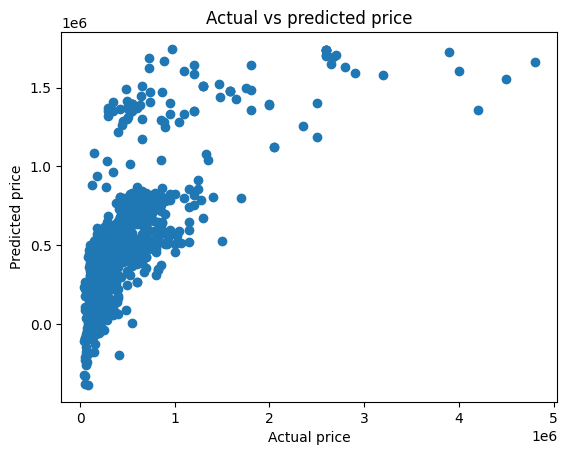

In [57]:
plt.scatter(y_test, y_hat)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs predicted price')
plt.show()